# LV9 - konvolucijske neuronske mreže (CNN)

- podvrsta dubokih neuronskih mreža
- najčešće se koriste u računalnom vidu (npr. klasifikacija slika)
- glavna prednost CNN-a je automatsko izdvajanje značajki iz slike (rubovi, teksture, oblici), bez ručnog definiranja značajki
- kao i u prošloj vježbi, koristit ćemo biblioteku keras

In [3]:
import keras
from keras import layers

### Slojevi konvolucijske neuronske mreže
- uobičajena struktura je ponavljanje blokova: Conv2D -> MaxPooling2D -> Dropout

1) konvolucijski sloj (Conv2D)
    - primjenjuje više filtara (kernela) nad ulaznom slikom/volumenom i stvara mape značajki
    - argument filters određuje broj filtara, a kernel_size njihovu veličinu (npr. 3x3, 5x5)
    - argument strides određuje pomak filtra, a padding ('same' ili 'valid') utječe na dimenzije izlaza
    - težine filtara su parametri koji se uče tijekom treniranja

2) aktivacijski sloj
    - nakon konvolucije uvodi se nelinearnost (najčešće ReLU)
    - bez nelinearnosti mreža bi bila ograničena na linearne transformacije

3) sloj sažimanja (MaxPooling2D)
    - smanjuje prostorne dimenzije mapa značajki (npr. 2x2 prozor)
    - zadržava najvažnije informacije (maksimalne vrijednosti) i smanjuje računsku složenost
    - nema parametre koji se uče

4) flatten sloj
    - pretvara 2D/3D mape značajki u 1D vektor
    - služi kao prijelaz prema potpuno povezanim slojevima

5) Potpuno povezani sloj (Dense)
    - njega već znamo iz prošle vježbe

In [ ]:
model = keras.Sequential()
model.add(layers.Input(shape=(32,32,3))) # 32x32 piksela, tri RGB vrijednosti
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

- dropout sloj
    - tijekom treniranja nasumično isključuje dio neurona (tipično rate 0.2 do 0.5)
    - smanjuje ovisnost modela o pojedinim neuronima i poboljšava generalizaciju

In [9]:
model.add(layers.Dropout(0.3))
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(500, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))

- nakon definiranja svih slojeva koje želimo, možemo definirati listu s funkcijama povratnog poziva (callbacks)
- njima možemo npr. periodički tijekom treniranja spremati model, podesiti rano zaustavljanje, podesiti alat tensorboard...
- naša callbacks lista koristit će se u fit() metodi modela
- neke korisne callback funkcije:
    - rano zaustavljanje (EarlyStopping)
        - prati metriku na validacijskom skupu (npr. val_loss)
        - ako nema poboljšanja kroz zadani broj epoha (patience), treniranje se zaustavlja
    - vizualizacija (Tensorboard)
        - prikazuje metrike tijekom treniranja u web pregledniku

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_cnn_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.TensorBoard(
        log_dir="logs/cnn9"
    )
]

- dalje su koraci jednaki kao i na prošloj vježbi - podešavamo model i učimo ga

In [10]:
model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

In [17]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

from keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model.fit(X_train,
            y_train,
            epochs = 40,
            batch_size = 64,
            callbacks = callbacks,
            validation_split = 0.1)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.4133 - loss: 1.6012 - val_accuracy: 0.5582 - val_loss: 1.2463
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.5720 - loss: 1.2022 - val_accuracy: 0.6550 - val_loss: 1.0137
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6313 - loss: 1.0385 - val_accuracy: 0.6794 - val_loss: 0.9150
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.6688 - loss: 0.9298 - val_accuracy: 0.6974 - val_loss: 0.8493
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7025 - loss: 0.8490 - val_accuracy: 0.7348 - val_loss: 0.7629
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7241 - loss: 0.7887 - val_accuracy: 0.7286 - val_loss: 0.7741
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7412 - loss: 0.7372 - val_accuracy: 0.7466 - val_loss: 0.7379
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7544 - loss: 0.6921 - 

- nakon pokretanja procesa učenja, moramo prvo pokrenuti tensorboard kako bismo mogli pratiti metrike koje on prikazuje
- postoji više načina:
    - na linuxu, otvoriti terminal u folderu gdje nam je logs folder i pokrenuti naredbu `tensorboard --logdir=logs`
    - na windowsu:
        - postoji ekstenzija tensorboard za vscode, ali meni ona nije radila
        - u teoriji bi trebala raditi i ova gore naredba, ali na kompjuterima na faksu nešto ne valja. može se pokrenuti ovako:
            1) `python -m pip install setuptools==81.0` (ako se javi greška da nema pkg_resources modul)
            2) `python -m tensorboard.main --logdir=logs`

- proces učenja je stao na 14. epohi, a kada otvorimo tensorboard možemo vidjeti i zašto:

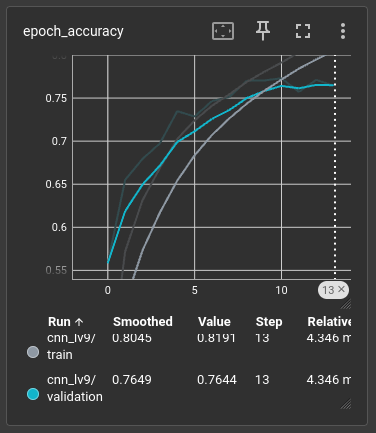

- iako je accuracy i dalje rastao na skupu za učenje, na skupu za validaciju je počeo stagnirati te bi daljnjim treniranjem mreže počeo opadati i mreža bi se overfittala.